In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator
import os
import numpy as np
from copy import deepcopy

In [3]:
import NNMFit
from NNMFit.utilities.readout_graphs import HistogramGraph
from NNMFit.core.analysis_config import AnalysisConfig

In [5]:
import sys
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks")
# from plot_utils import plot_histogram, plot_histogram_astro_flavor, plot_histogram_astro_newflavor
from plot_utils import plot_histogram

In [6]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/bdt_threshold_study_doub/event_rate"
os.system(f"mkdir -p {plotting_path}")

0

Overlap plots

First clean globalfit

----------
bdt1_0.333333_bdt2_0.366667
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


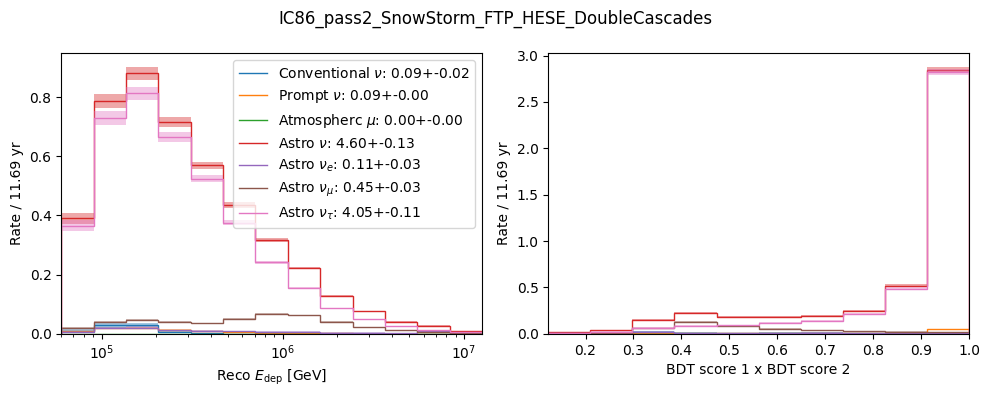

----------
bdt1_0.3_bdt2_0.366667
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


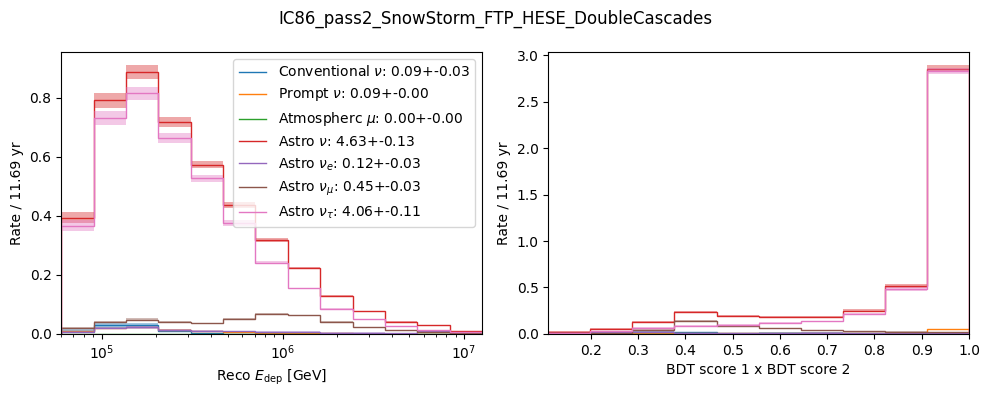

----------
bdt1_0.333333_bdt2_0.4
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


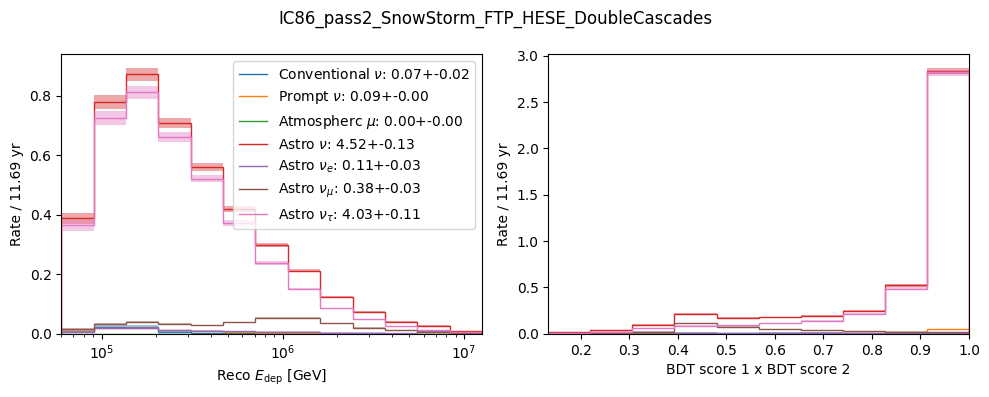

----------
bdt1_0.36_bdt2_0.366667
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


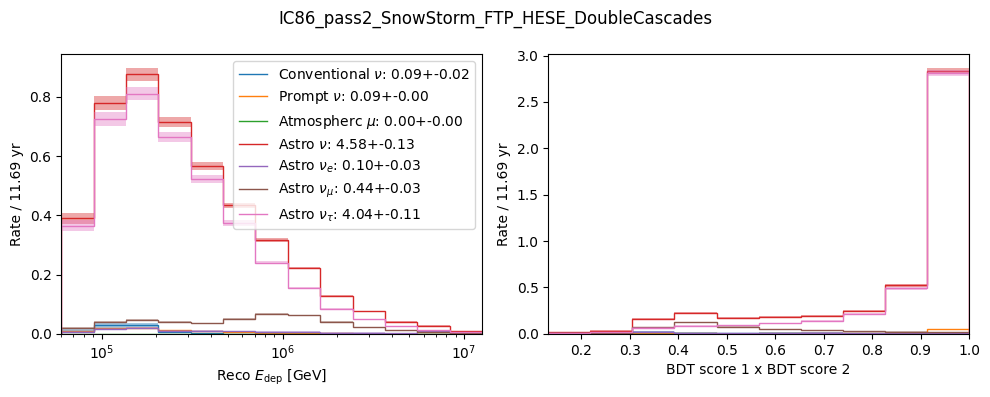

----------
bdt1_0.333333_bdt2_0.33
IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades


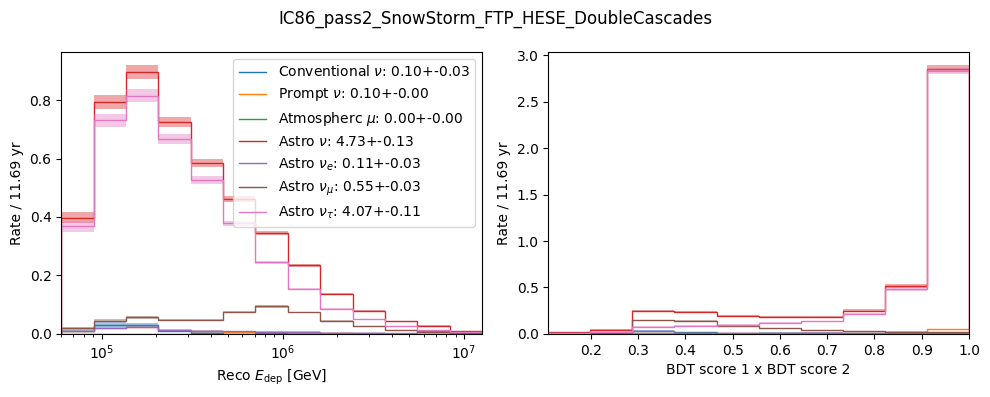

In [8]:
configs_dir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/configs/flavor_globalfit/"

for config in ["bdt1_0.333333_bdt2_0.366667",
               "bdt1_0.3_bdt2_0.366667", "bdt1_0.333333_bdt2_0.4",
               "bdt1_0.36_bdt2_0.366667", "bdt1_0.333333_bdt2_0.33"]:

    print(10*"-")
    print(config)

    config_hdl = AnalysisConfig.from_configs(
            main_config_file=f"{configs_dir}/main.cfg",
            analysis_config_file = f"{configs_dir}/analysis_configs/asimov/SAY/hese/hese_HESEBestfit_SPL_3flavor.yaml",
            config_dir=configs_dir,
            override_dict=None,
            override_config_files=["override/systematics/NoSystematics_hese.cfg",
                                  f"override/datasets_hese/variation_bdt_threshold_doug/{config}_length_10_fluxlessweight.cfg"],
            override_components_files=["override/components/astro_SPL_3flavor_no_inel.yaml",
                                    "override/muon/muontemplate_hese_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667.yaml"],
            override_parameters_files=None)
    hist_graph_hdl = HistogramGraph(config_hdl)
    detector_configs = config_hdl.get_det_configs()

    plotting_path_histogram = f"{plotting_path}/{config}"
    os.system(f"mkdir -p {plotting_path_histogram}")

    input_variables = {
        r"Conventional $\nu$" : {"total_astro_norm" : 0, "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 1, "muongun_norm" : 0},
        r"Prompt $\nu$" : {"total_astro_norm" : 0,  "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 1, "conv_norm" : 0, "muongun_norm" : 0},
        r"Atmospherc $\mu$" : {"total_astro_norm" : 0.0,  "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 1},
        r"Astro $\nu$" : {"total_astro_norm" : 6.3699,  "a" : 0.4444444444, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
        r"Astro $\nu_e$" : {"total_astro_norm" : 6.3699/3,  "a" : 1.0, "b" : 1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
        r"Astro $\nu_\mu$" : {"total_astro_norm" : 6.3699/3,  "a" : 1.0, "b" : -1.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
        r"Astro $\nu_\tau$" : {"total_astro_norm" : 6.3699/3,  "a" : 0.0, "b" : 0.0,"prompt_norm" : 0, "conv_norm" : 0, "muongun_norm" : 0},
    }

    for det_config in ["IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades"]: 
        plot_histogram(hist_graph_hdl=hist_graph_hdl, det_config=det_config, input_variables = input_variables, ylog=False, 
                    savepath=f"{plotting_path_histogram}/{det_config}_ylog-False.png")